In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

df = pd.read_csv('../data/Banking_Fraud_Dataset.csv')
df.head()

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Location,Transaction_Time,Device_Used,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud
0,T1,C2539,8527.58,Deposit,"Hughesmouth, Mongolia",2025-01-20 03:17:34,Mobile,16,740,0,0
1,T2,C5318,9275.82,Deposit,"Huntville, Saint Pierre and Miquelon",2025-01-03 18:08:56,Web,5,848,0,1
2,T3,C8262,2202.49,Online Payment,"Patriciashire, Iceland",2025-01-24 05:54:01,ATM,2,616,1,1
3,T4,C3865,9352.32,Deposit,"Port Timothymouth, Palau",2025-01-19 01:15:30,ATM,9,437,1,0
4,T5,C7248,2081.75,Online Payment,"Lake Stevenfurt, Mauritius",2025-01-08 18:06:13,ATM,15,494,0,0


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (10000, 11)

Columns:
['Transaction_ID', 'Customer_ID', 'Transaction_Amount', 'Transaction_Type', 'Transaction_Location', 'Transaction_Time', 'Device_Used', 'Account_Age', 'Credit_Score', 'Previous_Fraud', 'Is_Fraud']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        10000 non-null  str    
 1   Customer_ID           10000 non-null  str    
 2   Transaction_Amount    10000 non-null  float64
 3   Transaction_Type      10000 non-null  str    
 4   Transaction_Location  10000 non-null  str    
 5   Transaction_Time      10000 non-null  str    
 6   Device_Used           10000 non-null  str    
 7   Account_Age           10000 non-null  int64  
 8   Credit_Score          10000 non-null  int64  
 9   Previous_Fraud        10000 non-null  int64  
 10  Is_Fraud              10000 non-null  int64  
dtypes: 

Is_Fraud
0    7162
1    2838
Name: count, dtype: int64
Is_Fraud
0    71.62
1    28.38
Name: proportion, dtype: float64


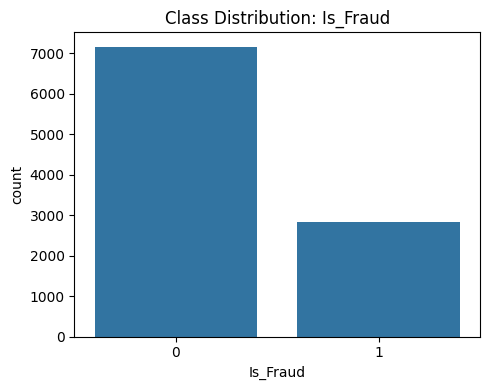

In [3]:
target_col = 'Is_Fraud'

print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=df)
plt.title('Class Distribution: Is_Fraud')
plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
target_col = 'Is_Fraud'
drop_cols = ['Transaction_ID', 'Customer_ID']

feature_cols = [c for c in df.columns if c not in drop_cols + [target_col]]
feature_cols

['Transaction_Amount',
 'Transaction_Type',
 'Transaction_Location',
 'Transaction_Time',
 'Device_Used',
 'Account_Age',
 'Credit_Score',
 'Previous_Fraud']

In [5]:
numeric_features = ['Transaction_Amount', 'Account_Age', 'Credit_Score', 'Previous_Fraud']
categorical_features = ['Transaction_Type', 'Transaction_Location', 'Transaction_Time', 'Device_Used']

numeric_features, categorical_features

(['Transaction_Amount', 'Account_Age', 'Credit_Score', 'Previous_Fraud'],
 ['Transaction_Type',
  'Transaction_Location',
  'Transaction_Time',
  'Device_Used'])

In [6]:
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((8000, 8), (2000, 8), np.float64(0.28375), np.float64(0.284))

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

numeric_features = ['Transaction_Amount', 'Account_Age', 'Credit_Score', 'Previous_Fraud']
categorical_features = ['Transaction_Type', 'Transaction_Location', 'Transaction_Time', 'Device_Used']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

clf_log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', log_reg)
])

In [8]:
#Training the baseline model
clf_log_reg.fit(X_train, y_train)

c:\Users\FOCO KONCEPT\OneDrive - Wrexham University\Documents\WREXHAM\Course Files\Github\advanced-ml-fraud-detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

              precision    recall  f1-score   support

           0     0.8314    0.7060    0.7636      1432
           1     0.4630    0.6391    0.5370       568

    accuracy                         0.6870      2000
   macro avg     0.6472    0.6725    0.6503      2000
weighted avg     0.7268    0.6870    0.6992      2000



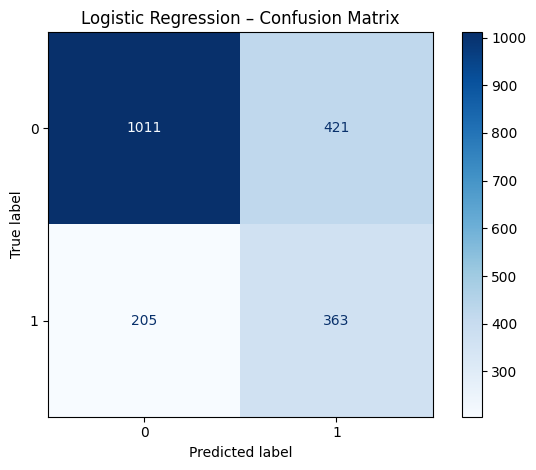

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = clf_log_reg.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Logistic Regression – Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/logreg_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

Random Forest:

              precision    recall  f1-score   support

           0     0.7523    0.9246    0.8296      1432
           1     0.5500    0.2324    0.3267       568

    accuracy                         0.7280      2000
   macro avg     0.6511    0.5785    0.5782      2000
weighted avg     0.6948    0.7280    0.6868      2000



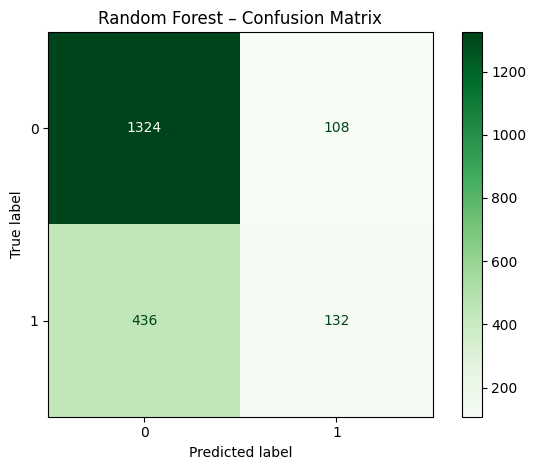

In [10]:
# Training Model 2 - Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf, digits=4))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[0, 1])
disp_rf.plot(cmap='Greens')
plt.title('Random Forest – Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

XGBoost:

              precision    recall  f1-score   support

           0     0.8176    0.6823    0.7438      1432
           1     0.4348    0.6162    0.5098       568

    accuracy                         0.6635      2000
   macro avg     0.6262    0.6492    0.6268      2000
weighted avg     0.7089    0.6635    0.6774      2000



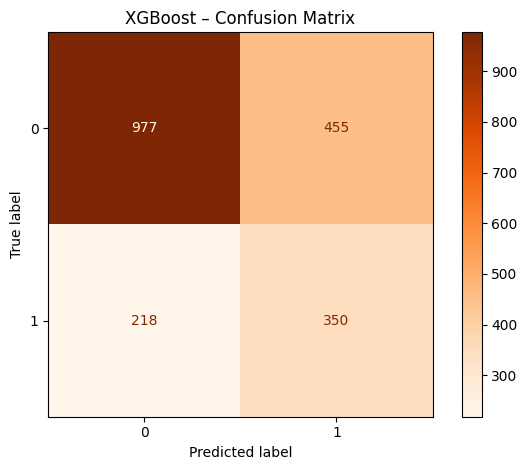

In [11]:
# Training Model 3 - XGBoost 
from xgboost import XGBClassifier

xgb_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_clf.fit(X_train, y_train)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_xgb = xgb_clf.predict(X_test)

print("XGBoost:\n")
print(classification_report(y_test, y_pred_xgb, digits=4))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=[0, 1])
disp_xgb.plot(cmap='Oranges')
plt.title('XGBoost – Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def model_metrics(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'model': name,
        'precision_1': precision_score(y_test, y_pred, pos_label=1),
        'recall_1': recall_score(y_test, y_pred, pos_label=1),
        'f1_1': f1_score(y_test, y_pred, pos_label=1),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

results = []
results.append(model_metrics('Logistic Regression', clf_log_reg, X_test, y_test))
results.append(model_metrics('Random Forest', rf_clf, X_test, y_test))
results.append(model_metrics('XGBoost', xgb_clf, X_test, y_test))

results_df = pd.DataFrame(results)
results_df

,model,precision_1,recall_1,f1_1,roc_auc
0,Logistic Regression,0.463010,0.639085,0.536982,0.736852
1,Random Forest,0.550000,0.232394,0.326733,0.738193
2,XGBoost,0.434783,0.616197,0.509832,0.710575


In [13]:
results_df.to_csv('../reports/model_comparison.csv', index=False)

In [14]:
final_model = clf_log_reg

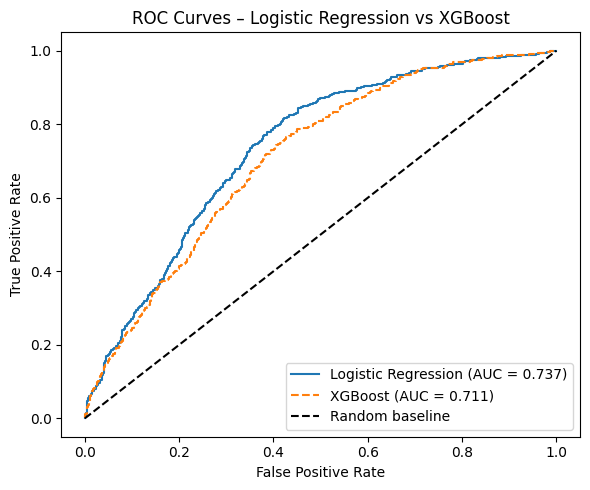

In [16]:
from sklearn.metrics import roc_curve, auc

# Get probabilities
y_proba_log = clf_log_reg.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

roc_auc_log = auc(fpr_log, tpr_log)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Logistic Regression vs XGBoost')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/roc_log_vs_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
import joblib

joblib.dump(final_model, '../models/final_logreg_pipeline.joblib')

['../models/final_logreg_pipeline.joblib']